# P11: Multi-class and regression

CPP compares exactly two groups: one **test group** against one **reference group**. Real datasets are often richer: several classes (enzyme families, localisation, substrate sub-types) or a continuous target (cleavage efficiency, binding affinity, stability). This protocol shows how to reach those settings without changing CPP at all, by **transforming the labels** with the `SequenceFeature.get_labels_*` helpers and looping the existing binary `CPP.run` over the resulting contrasts.

It builds directly on **P8: Classifier** (binary prediction) and reuses the same `DOM_GSEC` substrate dataset.

**When to use it.** Reach for this protocol when your labels are **not a single binary split**: you have three or more classes, or a continuous score you want CPP to explain. In glossary terms you are choosing a **contrast strategy** (how the test and reference groups are built) on top of CPP's binary core. *When not to use it:* if your task is already a clean two-group comparison, stay with the plain binary workflow in **P8: Classifier**.

**Key mental model.** CPP never becomes multi-class or regression-aware. Instead you decompose the harder task into a set of binary contrasts: one-vs-rest or one-vs-one for classes, quantile or tiered cuts for a continuous target. Each contrast is just a `labels` array (and, where samples are dropped, a matching `df_parts` subset) fed to the same `CPP.run`. The helpers that build these contrasts live on `SequenceFeature`, so the modelling step downstream is unchanged.

**Input.** The same `df_seq` as **P8: Classifier**: one row per protein with `tmd_start` / `tmd_stop` boundaries, loaded from the bundled `DOM_GSEC` set. The native binary `label` (1 = substrate, 0 = non-substrate) is the starting point; the multi-class and regression labels are derived from it below. As always, CPP consumes the **parts** table `df_parts` built by `SequenceFeature.get_df_parts`, not `df_seq` directly.

In [1]:
import aaanalysis as aa
import numpy as np
import pandas as pd

aa.options["verbose"] = False
aa.options["random_state"] = 42

# DOM_GSEC: gamma-secretase substrates (label 1, test group) vs
# non-substrates (label 0, reference group), with TMD boundaries.
df_seq = aa.load_dataset(name="DOM_GSEC", n=12)
labels = df_seq["label"].to_list()

sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
aa.display_df(df=df_seq[["entry", "label", "tmd_start", "tmd_stop"]], n_rows=5)

,entry,label,tmd_start,tmd_stop
1,Q14802,0,37,59
2,Q86UE4,0,50,72
3,Q969W9,0,41,63
4,P53801,0,97,119
5,Q8IUW5,0,59,81


**Run.** Three label strategies, one unchanged `CPP.run`. We start with the **binary baseline** (substrate vs non-substrate), the contrast **P8: Classifier** already uses. Its signature is the reference point for everything below. (`n_jobs=1` keeps this small demo deterministic.)

In [2]:
# Binary CPP: one test group vs one reference group (CPP's native mode).
df_feat_bin = aa.CPP(df_parts=df_parts).run(labels=labels, n_filter=20, n_jobs=1)
aa.display_df(df=df_feat_bin[["feature", "subcategory", "abs_auc", "mean_dif"]], n_rows=5)

,feature,subcategory,abs_auc,mean_dif
1,"JMD_N_TMD_N-Pat...,12)-PALJ810110",β-sheet,0.479000,-0.231000
2,"TMD-Pattern(N,1...,11)-PALJ810110",β-sheet,0.479000,-0.231000
3,"TMD_C_JMD_C-Pat...,12)-ISOY800105",β-sheet (C-term),0.479000,-0.180000
4,"JMD_N_TMD_N-Pat...,12)-FINA910103",α-helix (C-cap),0.469000,0.123000
5,"TMD-Pattern(N,1...,11)-FINA910103",α-helix (C-cap),0.469000,0.123000


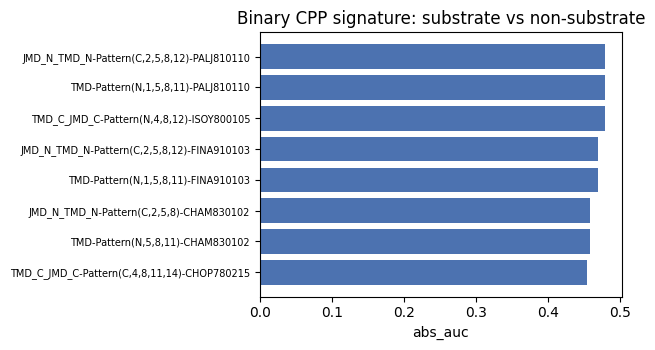

In [3]:
import matplotlib.pyplot as plt

# Headline figure: the top binary determinants by abs_auc.
top = df_feat_bin.nlargest(8, "abs_auc").iloc[::-1]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ypos = np.arange(len(top))
ax.barh(ypos, top["abs_auc"], color="#4C72B0")
ax.set_yticks(ypos)
ax.set_yticklabels(top["feature"], fontsize=7)
ax.set_xlabel("abs_auc")
ax.set_title("Binary CPP signature: substrate vs non-substrate")
plt.tight_layout()
plt.show()

**Multi-class labels (build the classes).** `DOM_GSEC` is binary, so we manufacture a three-class problem the way you would split a heterogeneous group into sub-types: cluster the **substrates** into two physicochemical groups with `AAclust` (clustered on a CPP **feature matrix**, so the sub-types are physicochemically meaningful) and keep the **non-substrates** as the third class. The result is a single integer `labels` array with values 0, 1, 2.

In [4]:
# Cluster substrates into two sub-types on a CPP feature matrix; non-substrates
# stay as the third class.
X = sf.feature_matrix(features=df_feat_bin["feature"], df_parts=df_parts, n_jobs=1)
sub_mask = np.array(labels) == 1

aac = aa.AAclust()
aac.fit(X[sub_mask], n_clusters=2)
sub_clusters = np.asarray(aac.labels_)          # 0 / 1 per substrate

multiclass = np.zeros(len(labels), dtype=int)   # class 0 = non-substrates
multiclass[sub_mask] = sub_clusters + 1         # class 1, 2 = substrate sub-types

df_classes = pd.DataFrame({
    "class": [0, 1, 2],
    "meaning": ["non-substrate", "substrate sub-type A", "substrate sub-type B"],
    "n": [int((multiclass == c).sum()) for c in (0, 1, 2)],
})
aa.display_df(df=df_classes)

,class,meaning,n
1,0,non-substrate,12
2,1,substrate sub-type A,6
3,2,substrate sub-type B,6


**Multi-class via one-vs-rest (OvR).** `get_labels_ovr` turns the three classes into three full-length binary arrays: each class in turn is the test group, everything else the reference. No samples are dropped, so all three reuse the same `df_parts`; you loop `CPP.run` once per class and read each class's own signature.

In [5]:
# One-vs-rest: each class becomes the test group (1) against all others (0).
dict_ovr = sf.get_labels_ovr(multiclass)
rows = []
for cls, y in dict_ovr.items():
    df_f = aa.CPP(df_parts=df_parts).run(labels=y, n_filter=10, n_jobs=1)
    top = df_f.iloc[0]
    rows.append({"class": int(cls), "n_test": int((y == 1).sum()),
                 "top_feature": top["feature"], "top_abs_auc": round(float(top["abs_auc"]), 3)})
aa.display_df(df=pd.DataFrame(rows))

,class,n_test,top_feature,top_abs_auc
1,0,12,"JMD_N_TMD_N-Pat...,12)-PALJ810110",0.479000
2,1,6,"TMD_C_JMD_C-Pat...,14)-AURR980110",0.500000
3,2,6,"JMD_N_TMD_N-Pat...,13)-ANDN920101",0.472000


**Multi-class via one-vs-one (OvO).** `get_labels_ovo` instead compares each **pair** of classes, discarding the others. Because samples are dropped, it returns per pair the row-matched `df_parts` copy alongside the labels (pass `dict_num_parts` instead for `CPP.run_num`), so each pair feeds `CPP.run` directly with no manual masking.

In [6]:
# One-vs-one: each class pair, other classes discarded. The helper subsets
# df_parts for us and returns the row-matched copy.
res_ovo = sf.get_labels_ovo(multiclass, df_parts=df_parts)
rows = []
for (a, b), (df_pair, _, y) in res_ovo.items():
    df_f = aa.CPP(df_parts=df_pair).run(labels=y, n_filter=10, n_jobs=1)
    top = df_f.iloc[0]
    rows.append({"pair": f"{a} vs {b}", "n": int(len(df_pair)),
                 "top_feature": top["feature"], "top_abs_auc": round(float(top["abs_auc"]), 3)})
aa.display_df(df=pd.DataFrame(rows))

,pair,n,top_feature,top_abs_auc
1,0 vs 1,18,"TMD-Pattern(C,4,8)-AURR980115",0.500000
2,0 vs 2,18,"JMD_N_TMD_N-Seg...,12)-KARS160115",0.500000
3,1 vs 2,12,"TMD_C_JMD_C-Pat...1,5)-ZIMJ680103",0.500000


**Regression labels (continuous target).** For a continuous score CPP still needs two groups, so we cut the score into a contrast. Here we attach a **random cleavage-efficiency** value to each substrate (replace with real measurements in practice) and turn it into labels two ways: `get_labels_quantile` for a single high-vs-low split, and `get_labels_tiered` for a fixed high-efficiency positive set compared against progressively stricter low-efficiency negatives.

In [7]:
# Continuous target: random cleavage efficiency per substrate (placeholder).
rng = np.random.default_rng(42)
df_parts_sub = df_parts[sub_mask]
efficiency = rng.uniform(0.0, 1.0, size=int(sub_mask.sum()))

# Single quantile cut: high (>= median) vs low efficiency. No samples dropped.
y_q = sf.get_labels_quantile(efficiency, q=0.5)
df_feat_q = aa.CPP(df_parts=df_parts_sub).run(labels=y_q, n_filter=15, n_jobs=1)
aa.display_df(df=df_feat_q[["feature", "subcategory", "abs_auc", "mean_dif"]], n_rows=5)

,feature,subcategory,abs_auc,mean_dif
1,"JMD_N_TMD_N-Pat...,11)-BULH740101",MPs (anchor),0.500000,0.396000
2,"TMD-Pattern(N,2...5,8)-BULH740101",MPs (anchor),0.500000,0.396000
3,"JMD_N_TMD_N-Pat...2,5)-SUEM840102",Unclassified (S...cture-Activity),0.500000,-0.377000
4,"TMD-Pattern(N,8,11)-SUEM840102",Unclassified (S...cture-Activity),0.500000,-0.377000
5,"JMD_N_TMD_N-Pat...,11)-PLIV810101",Partial specific volume,0.500000,-0.367000


In [8]:
# Tiered: fixed high-efficiency positives vs progressively stricter low-efficiency
# negatives; the middle band is dropped per tier. get_labels_tiered returns the
# row-matched df_parts per tier, ready for CPP.run.
res_tier = sf.get_labels_tiered(efficiency, q_pos=0.7, list_q_neg=[0.5, 0.3],
                                df_parts=df_parts_sub)
rows = []
for q_neg, (df_tier, _, y) in res_tier.items():
    df_f = aa.CPP(df_parts=df_tier).run(labels=y, n_filter=10, n_jobs=1)
    rows.append({"q_neg": q_neg, "n_samples": int(len(df_tier)),
                 "n_pos": int((y == 1).sum()), "top_feature": df_f.iloc[0]["feature"]})
aa.display_df(df=pd.DataFrame(rows))

,q_neg,n_samples,n_pos,top_feature
1,0.500000,10,4,"JMD_N_TMD_N-Pat...,11)-BULH740101"
2,0.300000,8,4,"JMD_N_TMD_N-Seg...,12)-AURR980115"


**How to interpret.**

| Output | Reading |
| --- | --- |
| OvR signature per class | the determinants that set **that class apart from all others**; compare top features across classes to see what is class-specific |
| OvO signature per pair | the determinants separating **two specific classes**, the sharper contrast when classes are similar |
| quantile signature | physicochemistry that tracks the **high vs low** end of the continuous target |
| tiered signatures across `q_neg` | features that **stay or strengthen** as the negative set gets more extreme are the most robust regression determinants |

**Key takeaways.**

- CPP stays binary; the `get_labels_*` helpers turn a harder task into a set of binary contrasts.
- OvR keeps all samples (shared `df_parts`); OvO and tiered drop samples and return the matching `df_parts` subset.
- The choice of **contrast strategy**, not a change to CPP, is what adapts the workflow to multi-class and regression.

**Common mistakes.**

- **Expecting a `CPP.fit_multiclass` / `fit_regression`.** There is none by design: build the contrasts with `get_labels_*` and loop `CPP.run`.
- **Applying a row mask by hand for OvO or tiered.** Pass `df_parts` (or `dict_num_parts`) to the helper and use the row-matched copy it returns.
- **Clustering on raw sequences for the multi-class split.** Cluster a CPP **feature matrix** (`SequenceFeature.feature_matrix`) so the sub-types are physicochemically meaningful.
- **Treating random cleavage-efficiency values as real signal.** They are a placeholder to demonstrate the API: swap in measured targets before drawing biology.

**Next step.** To turn any one of these contrasts into a working predictor with cross-validated metrics and per-protein scores, return to **P8: Classifier**; for leak-free evaluation of the selected features, see **P9: Interpretability** and **P10: Validation**.